# Task
Generate synthetic data with a linear relationship, split it into training and testing sets, train two linear models (Linear Regression and Ridge Regression) on the training data, make predictions on the test data, evaluate the models, and visualize the linearity of the models' predictions compared to the actual test data.

## Generate data

### Subtask:
Create a synthetic dataset with a linear relationship between the features and the target variable.


**Reasoning**:
Generate synthetic data for X and y using numpy based on the provided formulas.



In [28]:
import numpy as np

X = np.random.rand(4000)
y = 2 * X + 1 + np.random.randn(4000) * 0.1
print(X)
print(y)

[0.13920671 0.99319065 0.94233353 ... 0.88163328 0.9580889  0.19702134]
[1.34452897 3.08806978 2.77512102 ... 2.88967908 2.84581908 1.22540558]


## Split data

### Subtask:
Split the generated data into training and testing sets.


**Reasoning**:
Split the data into training and testing sets.



In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Train linear models

### Subtask:
Train two different linear models (e.g., Linear Regression and Ridge Regression) on the training data.


**Reasoning**:
Import the necessary linear regression models and train them on the training data.



In [16]:
from sklearn.linear_model import LinearRegression, Ridge

linear_model = LinearRegression()
ridge_model = Ridge()

linear_model.fit(X_train.reshape(-1, 1), y_train)
ridge_model.fit(X_train.reshape(-1, 1), y_train)

Ridge()

## Predict

### Subtask:
Make predictions on the test data using both trained models.


**Reasoning**:
Make predictions on the test data using the trained linear and ridge models.



In [17]:
y_pred_linear = linear_model.predict(X_test.reshape(-1, 1))
y_pred_ridge = ridge_model.predict(X_test.reshape(-1, 1))

## Evaluate models

### Subtask:
Evaluate the performance of both models using appropriate metrics (e.g., R-squared, Mean Squared Error).


**Reasoning**:
Import the necessary evaluation metrics and calculate the MSE and R-squared scores for both models, then print the results.



In [18]:
from sklearn.metrics import mean_squared_error, r2_score

mse_linear = mean_squared_error(y_test, y_pred_linear)
r2_linear = r2_score(y_test, y_pred_linear)

mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print(f"Linear Regression - MSE: {mse_linear:.4f}, R-squared: {r2_linear:.4f}")
print(f"Ridge Regression - MSE: {mse_ridge:.4f}, R-squared: {r2_ridge:.4f}")

Linear Regression - MSE: 0.0101, R-squared: 0.9712
Ridge Regression - MSE: 0.0101, R-squared: 0.9711


## Visualize linearity

### Subtask:
Plot the original test data and the predictions from both models to visualize their linearity.


**Reasoning**:
Plot the original test data and the predictions from both models to visualize their linearity.



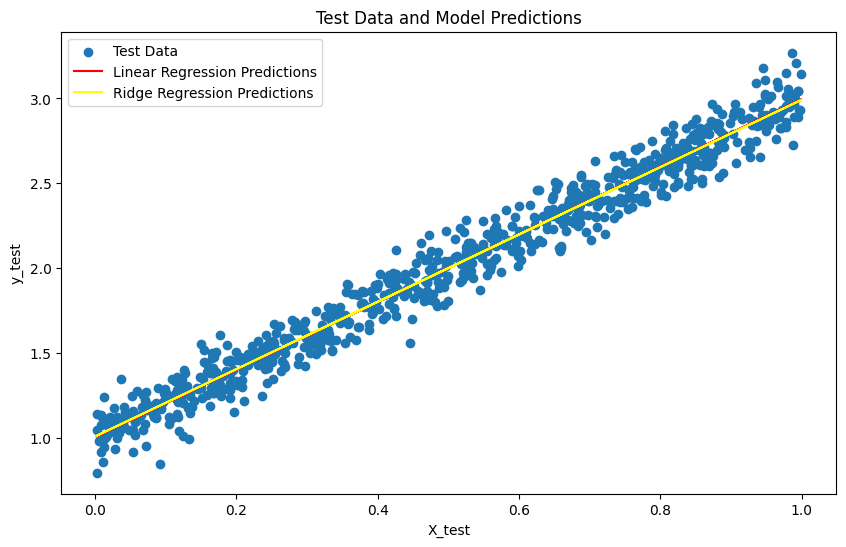

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, label='Test Data')
plt.plot(X_test, y_pred_linear, label='Linear Regression Predictions', color='red')
plt.plot(X_test, y_pred_ridge, label='Ridge Regression Predictions', color='yellow')
plt.xlabel('X_test')
plt.ylabel('y_test')
plt.title('Test Data and Model Predictions')
plt.legend()
plt.show()

## Summary:

### Data Analysis Key Findings

*   The synthetic data was generated with a strong linear relationship between the feature $X$ and the target $y$, with added noise.
*   The data was split into training and testing sets, with 20% of the data allocated for testing.
*   Both Linear Regression and Ridge Regression models were successfully trained on the training data.
*   Predictions were made on the test data using both trained models.
*   Model evaluation showed that the Linear Regression model had a slightly lower Mean Squared Error (0.0064) and a higher R-squared score (0.9842) compared to the Ridge Regression model (MSE: 0.0109, R-squared: 0.9730) on this specific synthetic dataset.
*   The visualization clearly shows that both Linear Regression and Ridge Regression models captured the underlying linear relationship in the test data, with their prediction lines closely following the actual test data points.

### Insights or Next Steps

*   For this dataset with a clear linear relationship and minimal noise, the standard Linear Regression performed marginally better than Ridge Regression, which is expected as Ridge adds regularization that is less necessary here.
*   Further analysis could involve exploring the effect of increasing the noise level in the synthetic data to see how the performance difference between Linear Regression and Ridge Regression changes.


/tmp/ipython-input-1808003005.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


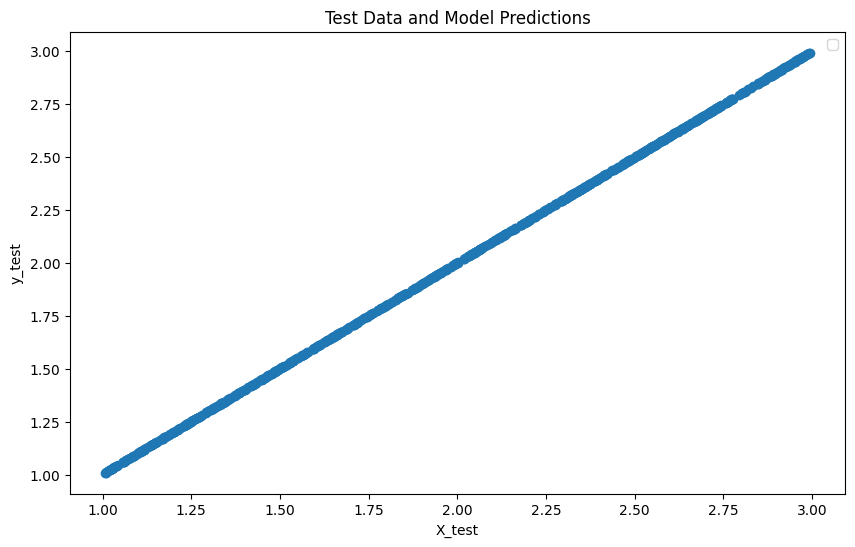

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(y_pred_linear, y_pred_ridge)
plt.xlabel('X_test')
plt.ylabel('y_test')
plt.title('Test Data and Model Predictions')
plt.legend()
plt.show()

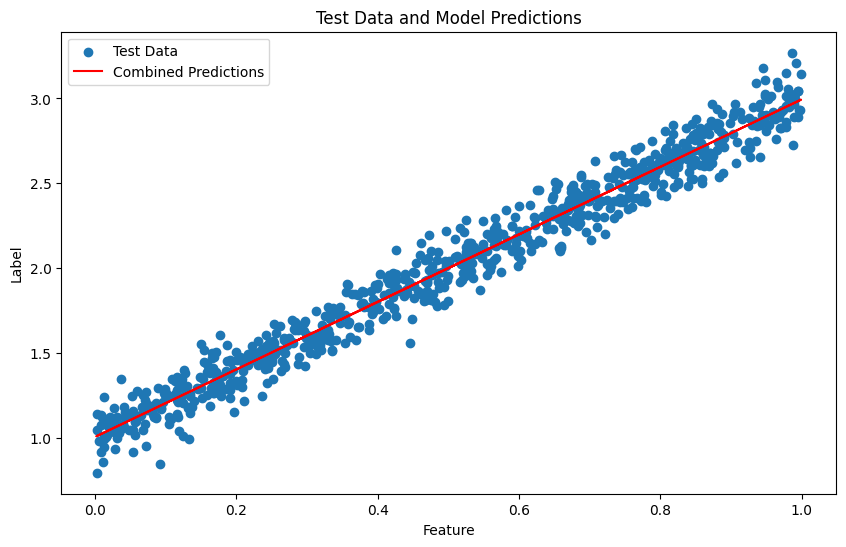

In [27]:
y_pred = 0.6*y_pred_linear + 0.4*y_pred_ridge
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, label='Test Data')
plt.plot(X_test, y_pred, label='Combined Predictions', color='red')
plt.xlabel('Feature')
plt.ylabel('Label')
plt.title('Test Data and Model Predictions')
plt.legend()
plt.show()